C:\Users\UDA\AppData\Local\Temp\ipykernel_20020\4097437472.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{v:.3f}°" for v in lons], fontsize=7)
C:\Users\UDA\AppData\Local\Temp\ipykernel_20020\4097437472.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.3f}°" for v in lats], fontsize=7)
C:\Users\UDA\AppData\Local\Temp\ipykernel_20020\4097437472.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{v:.3f}°" for v in lons], fontsize=7)
C:\Users\UDA\AppData\Local\Temp\ipykernel_20020\4097437472.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.3f}°" for 

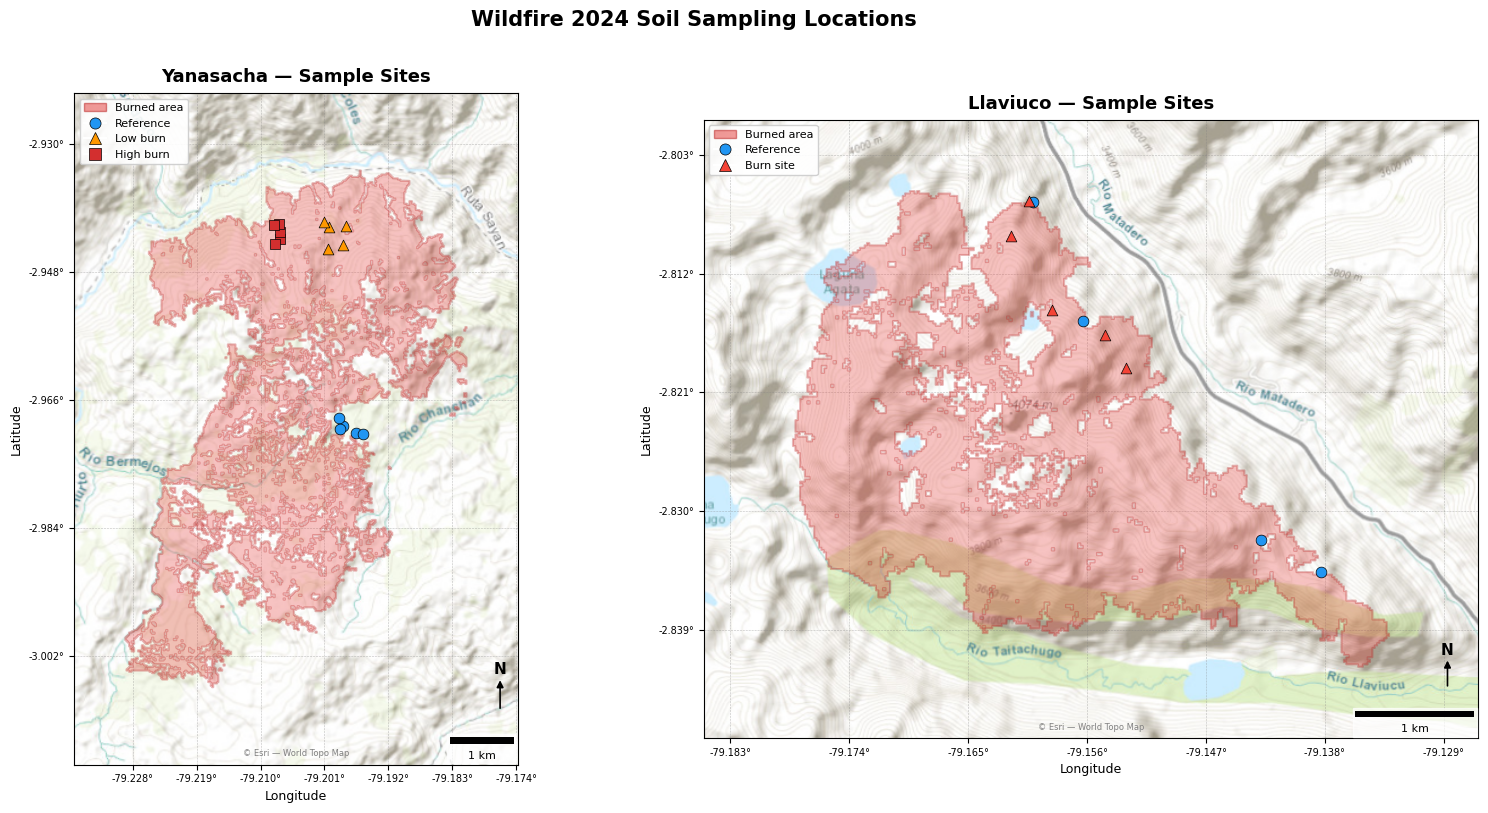

Saved -> maps\site_map_yanasacha_llaviuco.png


In [5]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx
from pyproj import Transformer
import numpy as np

PROJ_CRS = "EPSG:32717"  # UTM Zone 17S

# ── Load fire delineation polygons ──────────────────────────────────────────
llaviuco_fire = gpd.read_file(r"C:\Soilgrids\Llaviuco\NBR\Llaviuco.shp").to_crs(PROJ_CRS)
yanasacha_fire = gpd.read_file(r"C:\Soilgrids\Yanasacha\Yanasacha.shp").to_crs(PROJ_CRS)

# ── Load sample sites ────────────────────────────────────────────────────────
ll_df = pd.read_csv(r"C:\Soilgrids\datos_martha\sites_Llaviuco_clean.csv")
ya_df = pd.read_csv(r"C:\Soilgrids\datos_martha\sites_Yanasascha_clean.csv")

def csv_to_gdf(df):
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["Lon"], df["Lat"]),
        crs="EPSG:4326",
    ).to_crs(PROJ_CRS)

ll_sites = csv_to_gdf(ll_df)
ya_sites = csv_to_gdf(ya_df)

# ── Classify sites ───────────────────────────────────────────────────────────
# Llaviuco: LR → Reference, LB → Burn
ll_sites["group"] = ll_sites["Reference"].apply(
    lambda r: "Reference" if str(r).startswith("LR") else "Burn site"
)

# Yanasacha: YL → Low burn, YH → High burn, YR → Reference
def ya_group(r):
    r = str(r)
    if r.startswith("YL"):
        return "Low burn"
    elif r.startswith("YH"):
        return "High burn"
    else:
        return "Reference"

ya_sites["group"] = ya_sites["Reference"].apply(ya_group)

# ── Colour & marker palettes ─────────────────────────────────────────────────
ll_palette = {
    "Reference": {"color": "#2196F3", "marker": "o"},
    "Burn site":  {"color": "#F44336", "marker": "^"},
}
ya_palette = {
    "Reference": {"color": "#2196F3", "marker": "o"},
    "Low burn":  {"color": "#FF9800", "marker": "^"},
    "High burn": {"color": "#D32F2F", "marker": "s"},
}

FIRE_COLOR   = "#E53935"
FIRE_ALPHA   = 0.30
FIRE_EDGE    = "#B71C1C"
MARKER_SIZE  = 60
PAD_FRAC     = 0.15   # padding around extents as fraction of range

def padded_extent(gdf_list, frac=PAD_FRAC):
    """Return (minx, miny, maxx, maxy) with proportional padding."""
    all_bounds = [g.total_bounds for g in gdf_list]
    minx = min(b[0] for b in all_bounds)
    miny = min(b[1] for b in all_bounds)
    maxx = max(b[2] for b in all_bounds)
    maxy = max(b[3] for b in all_bounds)
    dx = (maxx - minx) * frac
    dy = (maxy - miny) * frac
    return minx - dx, miny - dy, maxx + dx, maxy + dy

def add_latlon_ticks(ax, minx, miny, maxx, maxy, crs=PROJ_CRS):
    t = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    xt = ax.get_xticks()
    yt = ax.get_yticks()
    lons, _ = t.transform(xt, np.full_like(xt, (miny + maxy) / 2))
    _, lats = t.transform(np.full_like(yt, (minx + maxx) / 2), yt)
    ax.set_xticklabels([f"{v:.3f}°" for v in lons], fontsize=7)
    ax.set_yticklabels([f"{v:.3f}°" for v in lats], fontsize=7)

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Panel helper ─────────────────────────────────────────────────────────────
def draw_panel(ax, fire_gdf, sites_gdf, palette, title):
    minx, miny, maxx, maxy = padded_extent([fire_gdf, sites_gdf])
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_autoscale_on(False)

    ctx.add_basemap(ax, crs=PROJ_CRS, source=ctx.providers.Esri.WorldTopoMap,
                    zoom="auto", attribution=False)
    ax.text(0.5, 0.01, "© Esri — World Topo Map",
            transform=ax.transAxes, fontsize=6, color="gray",
            ha="center", va="bottom", zorder=10)

    # Fire delineation
    fire_gdf.plot(ax=ax, facecolor=FIRE_COLOR, edgecolor=FIRE_EDGE,
                  linewidth=1.5, alpha=FIRE_ALPHA, zorder=3)

    # Sample sites by group
    for group, style in palette.items():
        sub = sites_gdf[sites_gdf["group"] == group]
        if sub.empty:
            continue
        ax.scatter(sub.geometry.x, sub.geometry.y,
                   c=style["color"], marker=style["marker"],
                   s=MARKER_SIZE, edgecolors="black", linewidths=0.5,
                   zorder=5, label=group)

    # Legend
    handles = [
        mpatches.Patch(facecolor=FIRE_COLOR, edgecolor=FIRE_EDGE,
                       alpha=0.5, label="Burned area"),
    ]
    for group, style in palette.items():
        handles.append(
            Line2D([0], [0], marker=style["marker"], color="w",
                   markerfacecolor=style["color"], markeredgecolor="black",
                   markeredgewidth=0.5, markersize=8, label=group)
        )
    ax.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.9)

    # North arrow
    ax.annotate("N", xy=(0.96, 0.13), xycoords="axes fraction",
                fontsize=11, fontweight="bold", ha="center", va="bottom")
    ax.annotate("", xy=(0.96, 0.13), xytext=(0.96, 0.08),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", lw=1.2, color="black"))

    # Scale bar
    ax.add_artist(ScaleBar(1, units="m", location="lower right",
                           length_fraction=0.20, box_alpha=0.7,
                           font_properties={"size": 8}))

    # Tick labels → lat/lon
    add_latlon_ticks(ax, minx, miny, maxx, maxy)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5, color="gray")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)

draw_panel(axes[0], yanasacha_fire, ya_sites, ya_palette,
           "Yanasacha — Sample Sites")
draw_panel(axes[1], llaviuco_fire,  ll_sites, ll_palette,
           "Llaviuco — Sample Sites")

plt.suptitle("Wildfire 2024 Soil Sampling Locations", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()

output_dir = "maps"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "site_map_yanasacha_llaviuco.png")
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {output_path}")


C:\Users\UDA\AppData\Local\Temp\ipykernel_20020\2262601297.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{lon:.3f}°" for lon in lon_labels])
C:\Users\UDA\AppData\Local\Temp\ipykernel_20020\2262601297.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{lat:.3f}°" for lat in lat_labels])


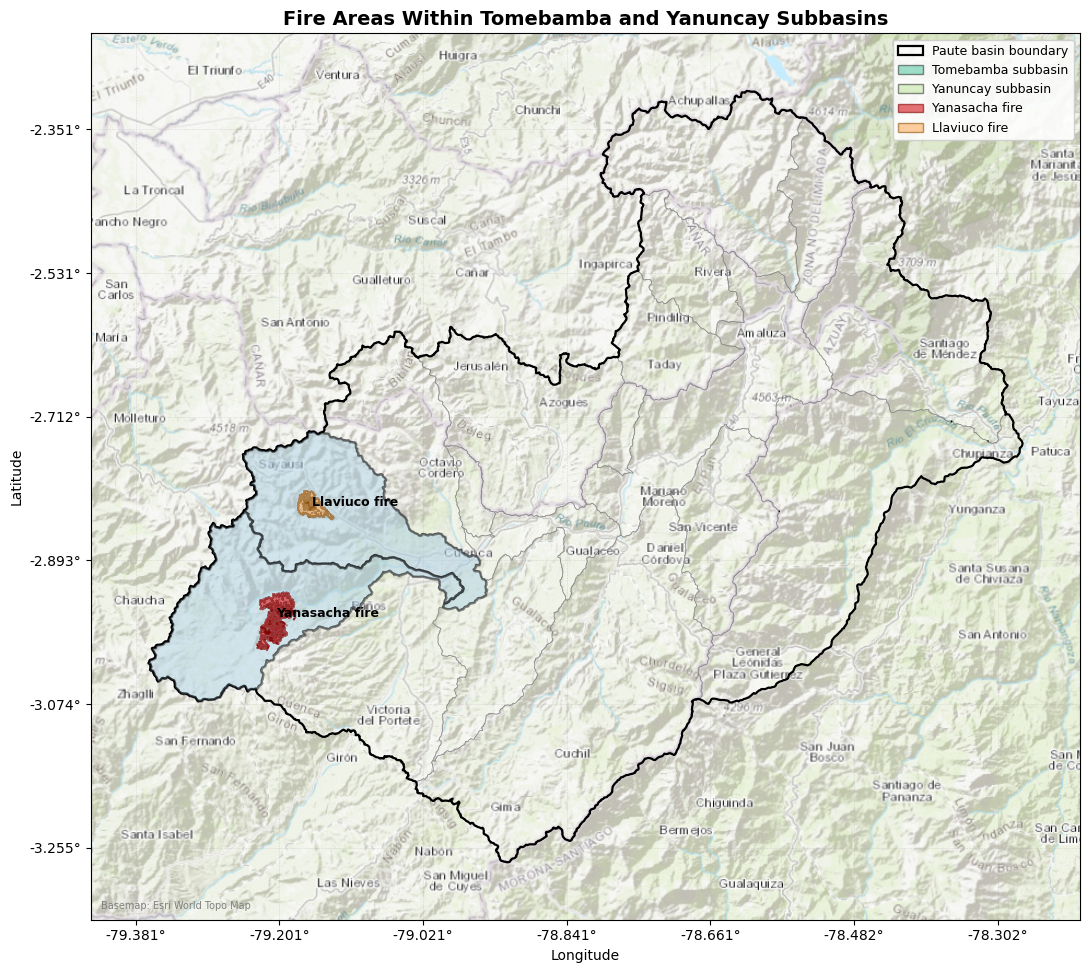

Saved: C:\Soilgrids\maps\fires_in_paute_subbasins.png


In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import contextily as ctx
import numpy as np
from pyproj import Transformer
import matplotlib.patches as mpatches

PROJ_CRS = "EPSG:32717"

def find_repo_root(start: Path) -> Path:
    """Find workspace root (folder containing Llaviuco and Yanasacha)."""
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "Llaviuco").exists() and (candidate / "Yanasacha").exists():
            return candidate
    return start.resolve()

repo_root = find_repo_root(Path.cwd())

# Inputs (robust to running notebook from figures/ or project root)
cuencas_dir = repo_root / "data" / "cuencas"
subbasins_all = gpd.read_file(cuencas_dir / "SubcuencasPaute.gpkg")
selected_subbasins = gpd.read_file(cuencas_dir / "Tomebamba_Yanuncay.gpkg")
llaviuco_fire = gpd.read_file(repo_root / "Llaviuco" / "NBR" / "Llaviuco.shp")
yanasacha_fire = gpd.read_file(repo_root / "Yanasacha" / "Yanasacha.shp")

# Harmonize CRS for mapping
subbasins_all = subbasins_all.to_crs(PROJ_CRS)
selected_subbasins = selected_subbasins.to_crs(PROJ_CRS)
llaviuco_fire = llaviuco_fire.to_crs(PROJ_CRS)
yanasacha_fire = yanasacha_fire.to_crs(PROJ_CRS)

# Build Paute basin outline from all subbasins
paute_outline = gpd.GeoDataFrame(
    geometry=[subbasins_all.union_all()],
    crs=subbasins_all.crs,
)

# Ensure map output folder exists
maps_dir = repo_root / "maps"
maps_dir.mkdir(parents=True, exist_ok=True)

# ------------------ MAP: regional context ------------------
minx, miny, maxx, maxy = subbasins_all.total_bounds
pad = 8000

fig, ax = plt.subplots(figsize=(11, 11))
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
ax.set_autoscale_on(False)

ctx.add_basemap(
    ax, crs=PROJ_CRS, source=ctx.providers.Esri.WorldTopoMap, zoom="auto", attribution=False
)
ax.text(
    0.01, 0.01, "Basemap: Esri World Topo Map",
    transform=ax.transAxes, fontsize=7, color="gray", ha="left", va="bottom"
)

# Draw layers
subbasins_all.boundary.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.7, zorder=2)
paute_outline.boundary.plot(ax=ax, color="black", linewidth=1.6, zorder=3)

subbasin_colors = {"Tomebamba": "#3ac79a", "Yanuncay": "#bfe49f"}
for _, row in selected_subbasins.iterrows():
    name = str(row.get("subbasin", "Subbasin"))
    color = subbasin_colors.get(name, "#a6cee3")
    gpd.GeoDataFrame(geometry=[row.geometry], crs=selected_subbasins.crs).plot(
        ax=ax, facecolor=color, edgecolor="black", linewidth=1.8, alpha=0.45, zorder=4
    )

yanasacha_fire.plot(
    ax=ax, facecolor="#d7191c", edgecolor="#7f0000", alpha=0.60, linewidth=1.2, zorder=5
)
llaviuco_fire.plot(
    ax=ax, facecolor="#fdae61", edgecolor="#8c510a", alpha=0.60, linewidth=1.2, zorder=5
)

# Labels at fire centroids
for label, gdf in [("Yanasacha fire", yanasacha_fire), ("Llaviuco fire", llaviuco_fire)]:
    c = gdf.union_all().centroid
    ax.text(c.x, c.y, label, fontsize=9, fontweight="bold", color="black", zorder=6)

# Convert axis ticks from projected coordinates to longitude/latitude
to_wgs84 = Transformer.from_crs(PROJ_CRS, "EPSG:4326", always_xy=True)
xticks = ax.get_xticks()
yticks = ax.get_yticks()
lon_labels, _ = to_wgs84.transform(xticks, np.full_like(xticks, (miny + maxy) / 2))
_, lat_labels = to_wgs84.transform(np.full_like(yticks, (minx + maxx) / 2), yticks)
ax.set_xticklabels([f"{lon:.3f}°" for lon in lon_labels])
ax.set_yticklabels([f"{lat:.3f}°" for lat in lat_labels])

# Legend
legend_handles = [
    mpatches.Patch(facecolor="none", edgecolor="black", linewidth=1.6, label="Paute basin boundary"),
    mpatches.Patch(facecolor="#2fbd90", edgecolor="black", alpha=0.45, label="Tomebamba subbasin"),
    mpatches.Patch(facecolor="#b2df8a", edgecolor="black", alpha=0.45, label="Yanuncay subbasin"),
    mpatches.Patch(facecolor="#d7191c", edgecolor="#7f0000", alpha=0.60, label="Yanasacha fire"),
    mpatches.Patch(facecolor="#fdae61", edgecolor="#8c510a", alpha=0.60, label="Llaviuco fire"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)

ax.set_title("Fire Areas Within Tomebamba and Yanuncay Subbasins", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.4)
plt.tight_layout()

map1_out = maps_dir / "fires_in_paute_subbasins.png"
plt.savefig(map1_out, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: {map1_out}")